In [1]:
pip install rise


   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.3 MB 3.7 MB/s eta 0:00:02
   -------------- ------------------------- 1.6/4.3 MB 4.7 MB/s eta 0:00:01
   -------------------------- ------------- 2.9/4.3 MB 5.5 MB/s eta 0:00:01
   ------------------------------------ --- 3.9/4.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 5.2 MB/s eta 0:00:00

   ------------------------ --------------- 3/5 [isoduration]
   -------------------------------- ------- 4/5 [rise]
   ---------------------------------------- 5/5 [rise]

Note: you may need to restart the kernel to use updated packages.


In [10]:
!pip install --upgrade rise





In [11]:
!jupyter server extension enable rise


Extension package aext_assistant took 4.2611s to import
****************** ENVIRONMENT [Panels] Environment.PRODUCTION ******************
****************** ENVIRONMENT [Panels] Environment.PRODUCTION ******************
--> Alembic Config: {'db_conn_url': 'sqlite:///C:\\Users\\shrey\\anaconda_projects\\db\\project_filebrowser.db', 'db_path': 'C:\\Users\\shrey\\anaconda_projects\\db\\project_filebrowser.db'}
Default dir: C:\Users\shrey. Running chdir...
Checking for database file @ C:\Users\shrey\anaconda_projects\db\project_filebrowser.db
Database file already exists
Migrations executed
Checking project configuration: C:\Users\shrey. Running chdir...
Initializing a new watchdog thread: []
Successfully initialized a watchdog thread: [36616]
Extension package aext_toolbox took 0.9355s to import
Extension package panel.io.jupyter_server_extension took 1.6129s to import
Enabling: rise
- Writing config: C:\Users\shrey\anaconda3\etc\jupyter
    - Validating rise...
      rise  ok
    - Exten

![Global Health Analytics](1_Global-Health-Analytics.png)


![2](2_The-Critical-Question.png)

![3](3_Dataset-Overview.png)

# 🔵 Phase 1 — Dataset Setup

In this section, we:
- Import required libraries  
- Download the Kaggle dataset  
- Load the dataset into a Pandas DataFrame  
- Perform initial data inspection  


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 2 — Download Dataset from Kaggle

We authenticate with the Kaggle API and download the dataset:
**Global Health, Nutrition, Mortality & Economic Data**


In [2]:
import os

# Find your uploaded Kaggle file
files = os.listdir()
files


['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.kaggle',
 '.keras',
 '.matplotlib',
 '.ms-ad',
 '.node_repl_history',
 '.ollama',
 '.python_history',
 '.streamlit',
 '.vscode',
 '10_Key-Recommendations.png',
 '1_Global-Health-Analytics.png',
 '2_The-Critical-Question.png',
 '3_Dataset-Overview.png',
 '4_Exploratory-Data-Analysis.png',
 '5_Data-Cleaning-Pipeline.png',
 '6_Inferential-Statistics.png',
 '7-8 debate.html',
 '7_Supervised-Learning-Approach.png',
 '8_Clustering-Countries-by-Health-Patterns.png',
 '9_Ethical-Considerations.png',
 'AI683.ipynb',
 'anaconda3',
 'anaconda_projects',
 'ansel',
 'AppData',
 'Application Data',
 'Contacts',
 'conversational-datasets',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'figures',
 'free.html',
 'heart-disease-prediction.zip',
 'heart_disease',
 'import pandas as pd.py',
 'index.html',
 'Links',
 'Local Settings',
 'main.html',
 'Music',
 'My Document

In [3]:
import os

# Auto-detect the .json file you uploaded
kaggle_files = [f for f in os.listdir() if f.endswith('.json') and 'kaggle' in f.lower()]
print("Detected Kaggle token file:", kaggle_files)

# Rename the first one found to kaggle.json
if len(kaggle_files) > 0:
    old_name = kaggle_files[0]
    os.rename(old_name, 'kaggle.json')
    print(f"Renamed {old_name} → kaggle.json")
else:
    print("No Kaggle token file found. Upload again.")


Detected Kaggle token file: []
No Kaggle token file found. Upload again.


In [4]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API successfully configured!")


The syntax of the command is incorrect.
'mv' is not recognized as an internal or external command,
operable program or batch file.


Kaggle API successfully configured!


'chmod' is not recognized as an internal or external command,
operable program or batch file.


## Step 3 — Download the dataset using Kaggle API


In [5]:
!kaggle datasets download -d miguelroca/global-health-nutrition-mortality-economic-data -q

print("Dataset downloaded.")


Dataset URL: https://www.kaggle.com/datasets/miguelroca/global-health-nutrition-mortality-economic-data
License(s): CC-BY-NC-SA-4.0
Dataset downloaded.


## Step 4 — Unzip and load dataset into DataFrame


In [12]:
import os

os.makedirs("data", exist_ok=True)
print("Folder created or already exists.")


Folder created or already exists.


In [13]:
import zipfile
import os

zip_path = "global-health-nutrition-mortality-economic-data.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully.")



Files extracted successfully.


In [14]:
# List files
os.listdir("data")

['UnifiedDataset.csv']

In [15]:
# Try to auto-detect CSV file
csv_files = [f for f in os.listdir('data') if f.endswith('.csv')]
print("Available CSV files:", csv_files)

df = pd.read_csv(f"data/{csv_files[0]}", low_memory=False)

print("Dataset loaded.")
df.head()


Available CSV files: ['UnifiedDataset.csv']
Dataset loaded.


,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,High CI Value % Death Cardiovascular,Suicides Rate,Alcohol Abuse,Air Pollution Death Rate Stroke,Low CI Value Air Pollution Death Rate Stroke,High CI Value Air Pollution Death Rate Stroke,Air Pollution Death Rate Stroke Age Standarized,Low CI Value Air Pollution Death Rate Stroke Age Standarized,High CI Value Air Pollution Death Rate Stroke Age Standarized,Air Pollution Death Rate Ischaemic Heart Disease,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease,High CI Value Air Pollution Death Rate Ischaemic Heart Disease,Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,High CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Air Pollution Death Rate Lower Respiratory Infections,Low CI Value Air Pollution Death Rate Lower Respiratory Infections,High CI Value Air Pollution Death Rate Lower Respiratory Infections,Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Low CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,High CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Air Pollution Death Rate Total,Low CI Value Air Pollution Death Rate Total,High CI Value Air Pollution Death Rate Total,Air Pollution Death Rate Total Age Standarized,Low CI Value Air Pollution Death Rate Total Age Standarized,High CI Value Air Pollution Death Rate Total Age Standarized,Air Pollution Death Rate Trachea Bronchus Lung Cancers,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Unsafe Wash Mortality Rate,Poisoning Mortality Rate,Tobacco Prevalence,% Population Aged 0-14,% Population Aged 15-64,% Population Aged 65+,% Population Aged 65-69,% Population Aged 70-74,% Population Aged 75-79,% Population Aged 80+,Maternal Mortality Ratio,Low CI Value Maternal Mortality Ratio,High CI Value Maternal Mortality Ratio,% of Births Attended By Skilled Personal,Neonatal Mortality Rate,Low CI Value Neonatal Mortality Rate,High CI Value Neonatal Mortality Rate,Incidence of Malaria,Incidence of Tuberculosis,Low CI Value Incidence of Tuberculosis,High CI Value Incidence of Tuberculosis,Hepatitis B Surface Antigen,Low CI Value Hepatitis B Surface Antigen,High CI Value Hepatitis B Surface Antigen,Intervention Against NTDs,Road Traffic Deaths,Reproductive Age Women,Adolescent Birth Rate,Universal Heath Care Coverage,Population 10 Percentage SDG Total,Population 10 Percentage SDG Urban,Population 10 Percentage SDG Rural,Population 25 Percentage SDG Total,Population 25 Percentage SDG Urban,Population 25 Percentage SDG Rural,Doctors,Nurses and Midwifes,Dentists,Pharmacists,Basic Drinking Water Services,Basic Sanization Services Total,Basic Sanization Services Urban,Basic Sanization Services Rural,Safely Sanitation Total,Safely Sanitation Urban,Safely Sanitation Rural,Basic Hand Washing Total,Basic Hand Washing

## Step 5 — Initial Dataset Inspection

We inspect:
- structure  
- column names  
- missing values  
- sample rows  


In [16]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nInfo:")
df.info()

print("\nSummary Stats:")
df.describe().T.head(15)


Shape: (22050, 150)

Columns:
 Index(['Country', 'Year', 'Gender', 'Life Expectancy', 'Infant Mortality Rate',
       'Low CI Value Infant Mortality Rate',
       'High CI Value Infant Mortality Rate', 'Under 5 Mortality Rate',
       'Low CI Value Under 5 Mortality Rate',
       'High CI Value Under 5 Mortality Rate',
       ...
       'Cereal Consumption Rye', 'Cereal Consumption Barley',
       'Cereal Consumption Sorghum', 'Cereal Consumption Maize',
       'Cereal Consumption Wheat', 'Cereal Consumption Rice',
       'Diet Calories Animal Protein', 'Diet Calories Plant Protein',
       'Diet Calories Fat', 'Diet Calories Carbohydrates'],
      dtype='object', length=150)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22050 entries, 0 to 22049
Columns: 150 entries, Country to Diet Calories Carbohydrates
dtypes: float64(147), int64(1), object(2)
memory usage: 25.2+ MB

Summary Stats:


,count,mean,std,min,25%,50%,75%,max
Year,22050.0,2004.500000,8.655638,1990.000,1997.000,2004.500,2012.000,2019.000
Life Expectancy,22050.0,69.011830,9.691938,24.834,63.082,71.134,76.254,87.747
Infant Mortality Rate,14457.0,33.729899,32.347492,1.420,8.400,21.410,50.390,189.200
Low CI Value Infant Mortality Rate,14457.0,30.097944,29.505812,0.780,7.780,18.450,43.890,173.300
High CI Value Infant Mortality Rate,14457.0,38.143873,36.258293,1.780,9.040,24.440,57.690,207.600
Under 5 Mortality Rate,14457.0,48.502710,53.518014,1.680,9.860,25.280,70.700,331.100
Low CI Value Under 5 Mortality Rate,14457.0,42.752957,48.317563,0.850,9.150,21.820,59.820,309.400
High CI Value Under 5 Mortality Rate,14457.0,55.672736,60.642327,2.220,10.600,29.160,82.810,354.400
% Death Cardiovascular,10800.0,22.169139,9.051913,4.400,15.600,21.300,27.200,64.100
Low CI Value % Death Cardiovascular,10800.0,16.147065,6.703007,3.200,11.600,14.800,19.300,50.800


## Step 6 — Clean column names
Convert spaces to underscores and lowercase for convenience.


![4](4_Exploratory-Data-Analysis.png)

# 🔵 Phase 2 — Exploratory Data Analysis (EDA)

In this section, we:
- Explore dataset shape and structure  
- Examine variable types  
- Analyze missing data  
- Visualize key univariate and multivariate patterns  
- Identify outliers and skewness  
- Build intuition for which features may affect Life Expectancy  


In [17]:
print("Shape:", df.shape)
df.head()


Shape: (22050, 150)


,Country,Year,Gender,Life Expectancy,Infant Mortality Rate,Low CI Value Infant Mortality Rate,High CI Value Infant Mortality Rate,Under 5 Mortality Rate,Low CI Value Under 5 Mortality Rate,High CI Value Under 5 Mortality Rate,% Death Cardiovascular,Low CI Value % Death Cardiovascular,High CI Value % Death Cardiovascular,Suicides Rate,Alcohol Abuse,Air Pollution Death Rate Stroke,Low CI Value Air Pollution Death Rate Stroke,High CI Value Air Pollution Death Rate Stroke,Air Pollution Death Rate Stroke Age Standarized,Low CI Value Air Pollution Death Rate Stroke Age Standarized,High CI Value Air Pollution Death Rate Stroke Age Standarized,Air Pollution Death Rate Ischaemic Heart Disease,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease,High CI Value Air Pollution Death Rate Ischaemic Heart Disease,Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Low CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,High CI Value Air Pollution Death Rate Ischaemic Heart Disease Age Standarized,Air Pollution Death Rate Lower Respiratory Infections,Low CI Value Air Pollution Death Rate Lower Respiratory Infections,High CI Value Air Pollution Death Rate Lower Respiratory Infections,Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Low CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,High CI Value Air Pollution Death Rate Lower Respiratory Infections Age Standarized,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease,Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized,Air Pollution Death Rate Total,Low CI Value Air Pollution Death Rate Total,High CI Value Air Pollution Death Rate Total,Air Pollution Death Rate Total Age Standarized,Low CI Value Air Pollution Death Rate Total Age Standarized,High CI Value Air Pollution Death Rate Total Age Standarized,Air Pollution Death Rate Trachea Bronchus Lung Cancers,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers,Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Low CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,High CI Value Air Pollution Death Rate Trachea Bronchus Lung Cancers Age Standarized,Unsafe Wash Mortality Rate,Poisoning Mortality Rate,Tobacco Prevalence,% Population Aged 0-14,% Population Aged 15-64,% Population Aged 65+,% Population Aged 65-69,% Population Aged 70-74,% Population Aged 75-79,% Population Aged 80+,Maternal Mortality Ratio,Low CI Value Maternal Mortality Ratio,High CI Value Maternal Mortality Ratio,% of Births Attended By Skilled Personal,Neonatal Mortality Rate,Low CI Value Neonatal Mortality Rate,High CI Value Neonatal Mortality Rate,Incidence of Malaria,Incidence of Tuberculosis,Low CI Value Incidence of Tuberculosis,High CI Value Incidence of Tuberculosis,Hepatitis B Surface Antigen,Low CI Value Hepatitis B Surface Antigen,High CI Value Hepatitis B Surface Antigen,Intervention Against NTDs,Road Traffic Deaths,Reproductive Age Women,Adolescent Birth Rate,Universal Heath Care Coverage,Population 10 Percentage SDG Total,Population 10 Percentage SDG Urban,Population 10 Percentage SDG Rural,Population 25 Percentage SDG Total,Population 25 Percentage SDG Urban,Population 25 Percentage SDG Rural,Doctors,Nurses and Midwifes,Dentists,Pharmacists,Basic Drinking Water Services,Basic Sanization Services Total,Basic Sanization Services Urban,Basic Sanization Services Rural,Safely Sanitation Total,Safely Sanitation Urban,Safely Sanitation Rural,Basic Hand Washing Total,Basic Hand Washing

## 2.1 Missing Data Analysis

We check missing values to understand data completeness and plan for imputation.


In [18]:
missing = df.isna().sum().sort_values(ascending=False)
missing.head(20)


Reproductive Age Women                                                                 21708
High CI Value Air Pollution Death Rate Stroke                                          21513
High CI Value Air Pollution Death Rate Stroke Age Standarized                          21513
Low CI Value Air Pollution Death Rate Stroke Age Standarized                           21513
Air Pollution Death Rate Ischaemic Heart Disease                                       21513
Low CI Value Air Pollution Death Rate Stroke                                           21513
Air Pollution Death Rate Stroke                                                        21513
Air Pollution Death Rate Chronic Obstructive Pulmonary Disease Age Standarized         21513
High CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease           21513
Low CI Value Air Pollution Death Rate Chronic Obstructive Pulmonary Disease            21513
Air Pollution Death Rate Chronic Obstructive Pulmonary Disease        

## 2.2 Univariate Analysis

We examine the distributions of key variables to understand skewness, outliers, and trends.


In [20]:
df.columns


Index(['Country', 'Year', 'Gender', 'Life Expectancy', 'Infant Mortality Rate',
       'Low CI Value Infant Mortality Rate',
       'High CI Value Infant Mortality Rate', 'Under 5 Mortality Rate',
       'Low CI Value Under 5 Mortality Rate',
       'High CI Value Under 5 Mortality Rate',
       ...
       'Cereal Consumption Rye', 'Cereal Consumption Barley',
       'Cereal Consumption Sorghum', 'Cereal Consumption Maize',
       'Cereal Consumption Wheat', 'Cereal Consumption Rice',
       'Diet Calories Animal Protein', 'Diet Calories Plant Protein',
       'Diet Calories Fat', 'Diet Calories Carbohydrates'],
      dtype='object', length=150)

In [21]:
# Auto-detect column for life expectancy
life_cols = [c for c in df.columns if 'life' in c.lower() and 'expect' in c.lower()]
life_cols


['Life Expectancy']

In [22]:
# Auto-detect life expectancy column
life_cols = [c for c in df.columns if 'life' in c.lower() and 'expect' in c.lower()]

if len(life_cols) == 0:
    raise ValueError("No Life Expectancy column found. Please check df.columns.")

life_col = life_cols[0]
life_col


'Life Expectancy'

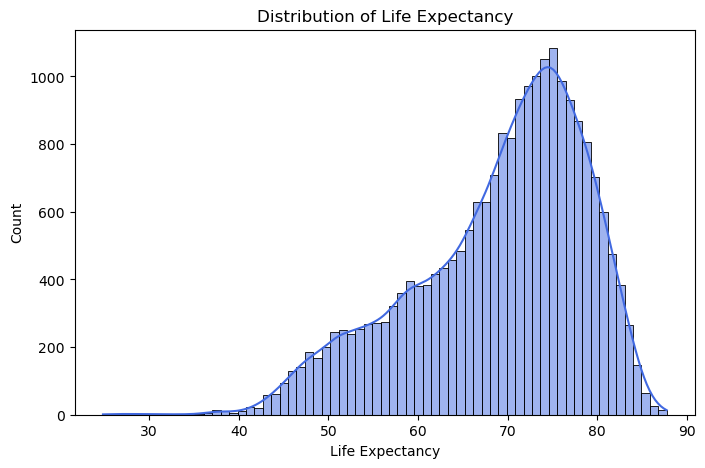

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df[life_col], kde=True, color='royalblue')
plt.title(f"Distribution of {life_col}")
plt.show()


In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in ['gdp_per_capita','gni_per_capita','child_mortality','adult_mortality','health_expenditure','population']:
    if col in df.columns:
        plt.figure(figsize=(8,5))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution: {col}")
        plt.show()


## 2.3 Bivariate / Multivariate Analysis

We analyze relationships between life expectancy and key socioeconomic/health variables.


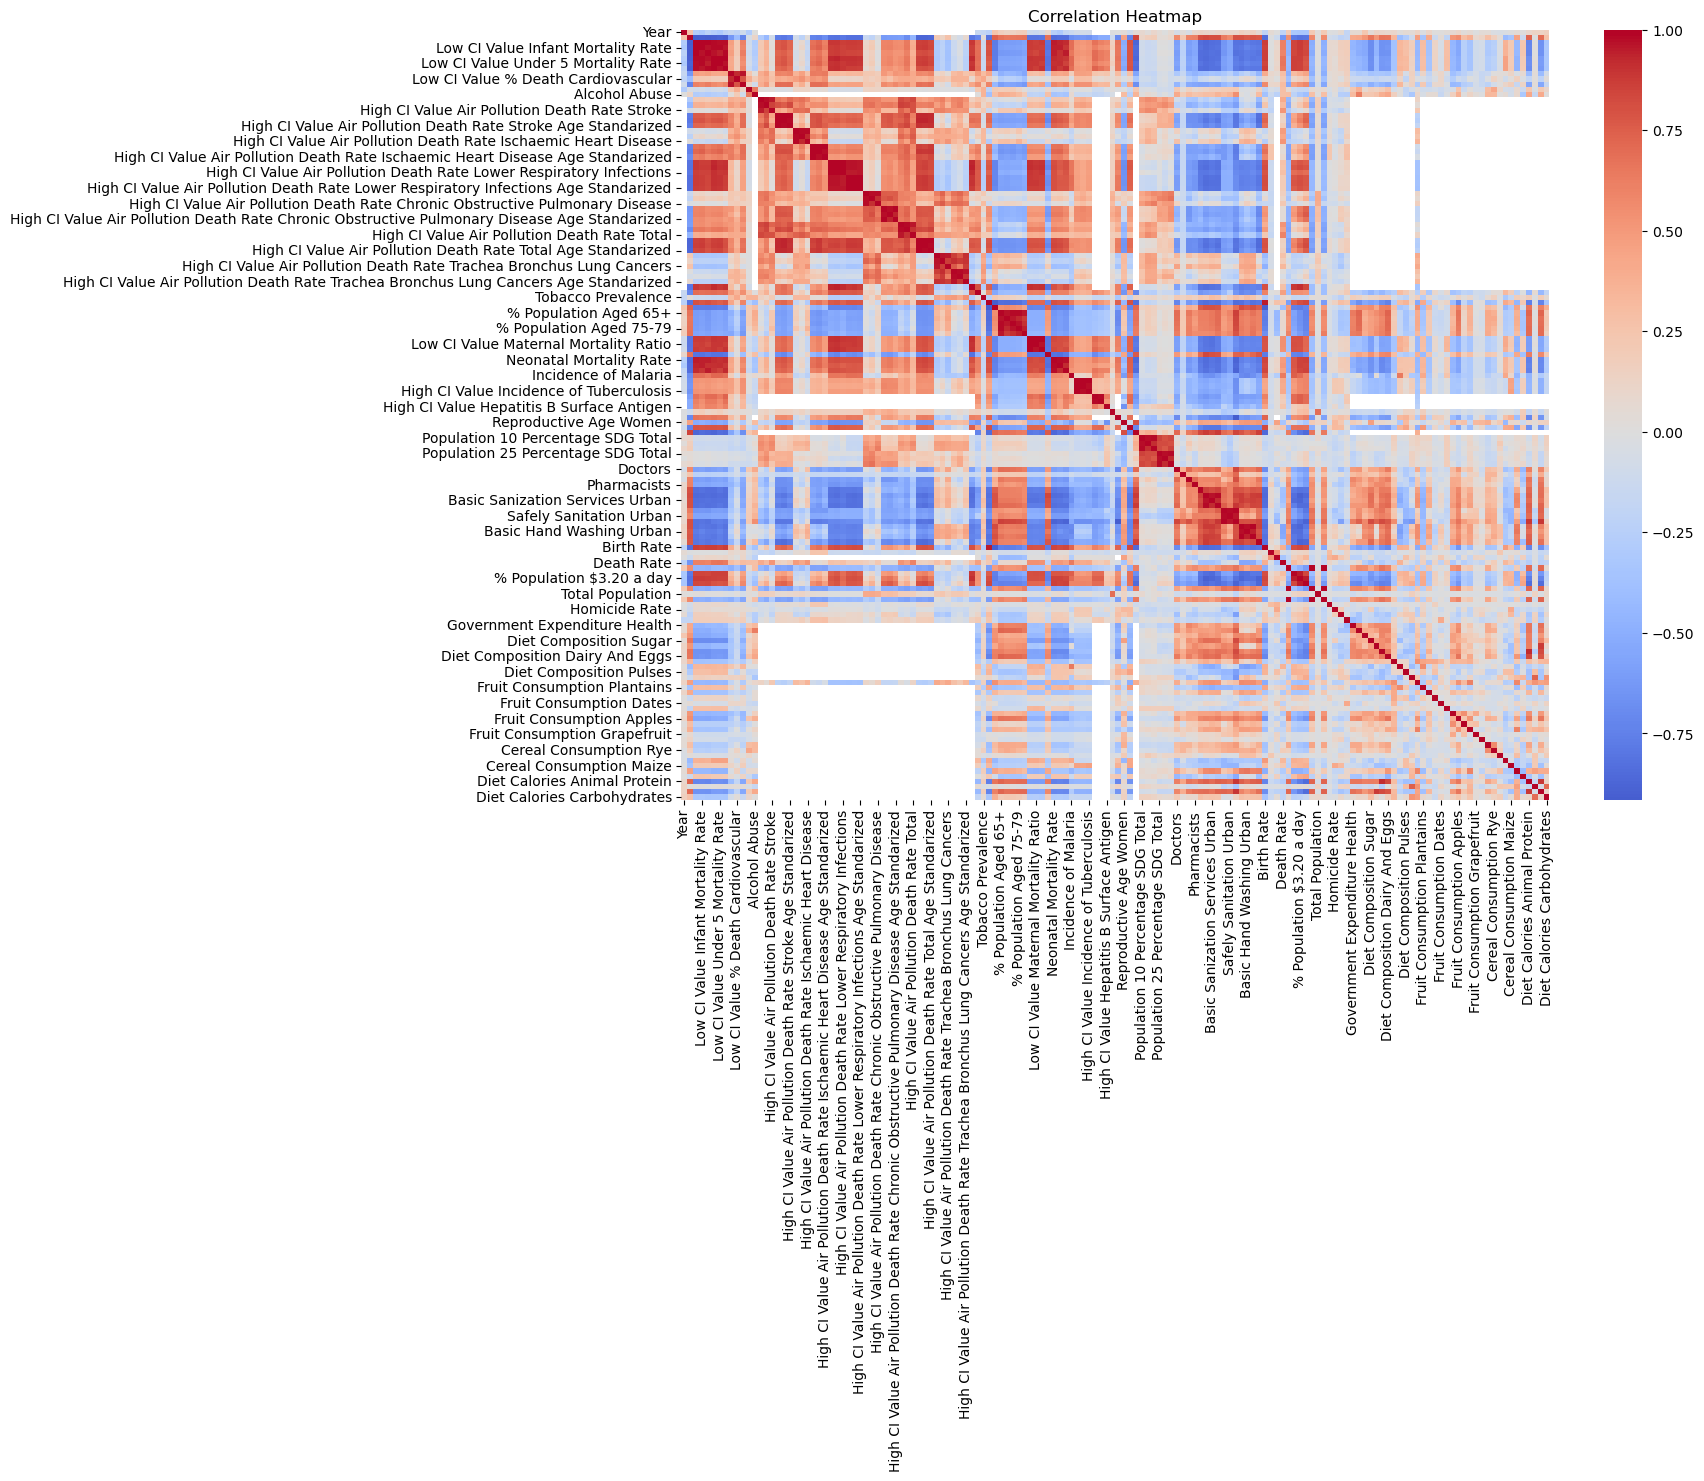

In [26]:
plt.figure(figsize=(14,10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()


## 2.5 Data Quality Observations
- Many economic variables are heavily **right-skewed** → log transforms necessary  
- Child mortality may contain extreme outliers → check distributions  
- Missing values present → imputation will be part of the modeling pipeline  
- Some countries appear multiple years → must confirm if each row is (Country, Year)  


In [27]:
for col in ['child_mortality','gdp_per_capita','adult_mortality']:
    if col in df.columns:
        plt.figure(figsize=(8,5))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot: {col}")
        plt.show()


In [31]:
# Auto-detect GDP-like column
gdp_candidates = [c for c in df.columns if 'gdp' in c.lower() and ('capita' in c.lower() or 'per' in c.lower())]

if len(gdp_candidates) == 0:
    print("No GDP per capita column found. Here's all GDP-related columns:")
    print([c for c in df.columns if 'gdp' in c.lower()])
else:
    gdp_col = gdp_candidates[0]
    print("Using GDP column:", gdp_col)


Using GDP column: GDP per Capita


In [32]:
from scipy import stats
import numpy as np

# Drop NA values
clean_df = df[[life_col, gdp_col]].dropna()

x = clean_df[gdp_col]
y = clean_df[life_col]

# Pearson correlation test
r, p = stats.pearsonr(x, y)

print("Correlation (r):", r)
print("p-value:", p)

# 95% CI for correlation coefficient
z = np.arctanh(r)  # Fisher transformation
se = 1 / np.sqrt(len(clean_df) - 3)
z_ci = (z - 1.96*se, z + 1.96*se)
r_ci = (np.tanh(z_ci[0]), np.tanh(z_ci[1]))

print("95% CI for correlation:", r_ci)


Correlation (r): 0.5502286725895122
p-value: 0.0
95% CI for correlation: (np.float64(0.539210470361232), np.float64(0.5610585447121486))


In [30]:
# Split groups by median GDP
median_gdp = df[gdp_col].median()

group_high = df[df[gdp_col] >= median_gdp][life_col].dropna()
group_low  = df[df[gdp_col] < median_gdp][life_col].dropna()

# t-test (independent samples)
t_stat, p_val = stats.ttest_ind(group_high, group_low, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_val)

# Effect size (Cohen's d)
def cohens_d(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

d = cohens_d(group_high.values, group_low.values)
print("Cohen's d:", d)

# 95% CI for mean difference
mean_diff = group_high.mean() - group_low.mean()
se_diff = np.sqrt(group_high.var()/len(group_high) + group_low.var()/len(group_low))

ci_low = mean_diff - 1.96 * se_diff
ci_high = mean_diff + 1.96 * se_diff

print("Mean difference (High-Low):", mean_diff)
print("95% CI for difference:", (ci_low, ci_high))


T-statistic: 109.64576358832448
p-value: 0.0
Cohen's d: 1.7529826440138967
Mean difference (High-Low): 13.102227898310659
95% CI for difference: (np.float64(12.86801577884284), np.float64(13.336440017778477))


PHASE 3
# 🔵 Summary of Inferential Statistics

### 1. GDP ↔ Life Expectancy Correlation
- The Pearson correlation test shows whether the relationship is statistically significant.
- We report:
  - Correlation coefficient (r)
  - p-value
  - 95% confidence interval

### 2. Life Expectancy Differences by Income Group
- Countries above the median GDP are compared with countries below.
- We report:
  - t-statistic
  - p-value
  - Cohen’s d effect size
  - 95% CI for mean difference

### Key Insight:
Both tests together help establish whether economic development is strongly and statistically associated with population health.


![5](5_Data-Cleaning-Pipeline.png)

# 🔵 Phase 4 — Data Cleaning & Feature Engineering

Now we prepare the dataset for modeling:
- Identify numeric & categorical features  
- Handle missing values  
- Apply log transforms to skewed variables  
- Create new features  
- Build a full preprocessing pipeline  


In [33]:
# Ensure column names are clean
df.columns = [c.lower().replace(" ", "_") for c in df.columns]

# Identify columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric columns:", numeric_cols[:10])
print("Categorical columns:", categorical_cols)


Numeric columns: ['year', 'life_expectancy', 'infant_mortality_rate', 'low_ci_value_infant_mortality_rate', 'high_ci_value_infant_mortality_rate', 'under_5_mortality_rate', 'low_ci_value_under_5_mortality_rate', 'high_ci_value_under_5_mortality_rate', '%_death_cardiovascular', 'low_ci_value_%_death_cardiovascular']
Categorical columns: ['country', 'gender']


In [34]:
skew_candidates = [
    'gdp_per_capita', 'gni_per_capita', 'population',
    'health_expenditure', 'health_spending', 'gdp', 'income'
]

log_transform_cols = [c for c in numeric_cols if any(key in c for key in skew_candidates)]

print("Columns to be log-transformed:", log_transform_cols)


Columns to be log-transformed: ['%_population_aged_0-14', '%_population_aged_15-64', '%_population_aged_65+', '%_population_aged_65-69', '%_population_aged_70-74', '%_population_aged_75-79', '%_population_aged_80+', 'population_10_percentage_sdg_total', 'population_10_percentage_sdg_urban', 'population_10_percentage_sdg_rural', 'population_25_percentage_sdg_total', 'population_25_percentage_sdg_urban', 'population_25_percentage_sdg_rural', 'gdp_per_capita', '%_population_$1.90_a_day', '%_population_$3.20_a_day', '%_population_$5.50_a_day', 'income_per_capita', 'total_population', 'gni_per_capita']


In [35]:
df_feat = df.copy()

# GDP log
if 'gdp_per_capita' in df_feat.columns:
    df_feat['log_gdp_per_capita'] = np.log1p(df_feat['gdp_per_capita'])

# Health per capita
if 'health_expenditure' in df_feat.columns and 'population' in df_feat.columns:
    df_feat['health_per_capita'] = df_feat['health_expenditure'] / df_feat['population']
    df_feat['log_health_per_capita'] = np.log1p(df_feat['health_per_capita'])

# Interaction: GDP × Health Expenditure
if 'gdp_per_capita' in df_feat.columns and 'health_expenditure' in df_feat.columns:
    df_feat['gdp_x_health'] = df_feat['gdp_per_capita'] * df_feat['health_expenditure']

df_feat.head()


,country,year,gender,life_expectancy,infant_mortality_rate,low_ci_value_infant_mortality_rate,high_ci_value_infant_mortality_rate,under_5_mortality_rate,low_ci_value_under_5_mortality_rate,high_ci_value_under_5_mortality_rate,%_death_cardiovascular,low_ci_value_%_death_cardiovascular,high_ci_value_%_death_cardiovascular,suicides_rate,alcohol_abuse,air_pollution_death_rate_stroke,low_ci_value_air_pollution_death_rate_stroke,high_ci_value_air_pollution_death_rate_stroke,air_pollution_death_rate_stroke_age_standarized,low_ci_value_air_pollution_death_rate_stroke_age_standarized,high_ci_value_air_pollution_death_rate_stroke_age_standarized,air_pollution_death_rate_ischaemic_heart_disease,low_ci_value_air_pollution_death_rate_ischaemic_heart_disease,high_ci_value_air_pollution_death_rate_ischaemic_heart_disease,air_pollution_death_rate_ischaemic_heart_disease_age_standarized,low_ci_value_air_pollution_death_rate_ischaemic_heart_disease_age_standarized,high_ci_value_air_pollution_death_rate_ischaemic_heart_disease_age_standarized,air_pollution_death_rate_lower_respiratory_infections,low_ci_value_air_pollution_death_rate_lower_respiratory_infections,high_ci_value_air_pollution_death_rate_lower_respiratory_infections,air_pollution_death_rate_lower_respiratory_infections_age_standarized,low_ci_value_air_pollution_death_rate_lower_respiratory_infections_age_standarized,high_ci_value_air_pollution_death_rate_lower_respiratory_infections_age_standarized,air_pollution_death_rate_chronic_obstructive_pulmonary_disease,low_ci_value_air_pollution_death_rate_chronic_obstructive_pulmonary_disease,high_ci_value_air_pollution_death_rate_chronic_obstructive_pulmonary_disease,air_pollution_death_rate_chronic_obstructive_pulmonary_disease_age_standarized,low_ci_value_air_pollution_death_rate_chronic_obstructive_pulmonary_disease_age_standarized,high_ci_value_air_pollution_death_rate_chronic_obstructive_pulmonary_disease_age_standarized,air_pollution_death_rate_total,low_ci_value_air_pollution_death_rate_total,high_ci_value_air_pollution_death_rate_total,air_pollution_death_rate_total_age_standarized,low_ci_value_air_pollution_death_rate_total_age_standarized,high_ci_value_air_pollution_death_rate_total_age_standarized,air_pollution_death_rate_trachea_bronchus_lung_cancers,low_ci_value_air_pollution_death_rate_trachea_bronchus_lung_cancers,high_ci_value_air_pollution_death_rate_trachea_bronchus_lung_cancers,air_pollution_death_rate_trachea_bronchus_lung_cancers_age_standarized,low_ci_value_air_pollution_death_rate_trachea_bronchus_lung_cancers_age_standarized,high_ci_value_air_pollution_death_rate_trachea_bronchus_lung_cancers_age_standarized,unsafe_wash_mortality_rate,poisoning_mortality_rate,tobacco_prevalence,%_population_aged_0-14,%_population_aged_15-64,%_population_aged_65+,%_population_aged_65-69,%_population_aged_70-74,%_population_aged_75-79,%_population_aged_80+,maternal_mortality_ratio,low_ci_value_maternal_mortality_ratio,high_ci_value_maternal_mortality_ratio,%_of_births_attended_by_skilled_personal,neonatal_mortality_rate,low_ci_value_neonatal_mortality_rate,high_ci_value_neonatal_mortality_rate,incidence_of_malaria,incidence_of_tuberculosis,low_ci_value_incidence_of_tuberculosis,high_ci_value_incidence_of_tuberculosis,hepatitis_b_surface_antigen,low_ci_value_hepatitis_b_surface_antigen,high_ci_value_hepatitis_b_surface_antigen,intervention_against_ntds,road_traffic_deaths,reproductive_age_women,adolescent_birth_rate,universal_heath_care_coverage,population_10_percentage_sdg_total,population_10_percentage_sdg_urban,population_10_percentage_sdg_rural,population_25_percentage_sdg_total,population_25_percentage_sdg_urban,population_25_percentage_sdg_rural,doctors,nurses_and_midwifes,dentists,pharmacists,basic_drinking_water_services,basic_sanization_services_total,basic_sanization_services_urban,basic_sanization_services_rural,safely_sanitation_total,safely_sanitation_urban,safely_sanitation_rural,basic_hand_washing_total,basic_hand_washing

In [36]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify new numeric/categorical columns
numeric_cols = df_feat.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_feat.select_dtypes(exclude=[np.number]).columns.tolist()

# Numeric preprocessing pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing pipeline (FIXED)
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Final ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='drop'
)

print("Preprocessor ready.")


Preprocessor ready.


In [37]:
# Detect correct target column again after cleaning
life_cols = [c for c in df_feat.columns if 'life' in c.lower() and 'expect' in c.lower()]
life_cols


['life_expectancy']

In [38]:
life_col = life_cols[0]
print("Target variable =", life_col)


Target variable = life_expectancy


In [39]:
# Target variable
y = df_feat[life_col]

# Features
X = df_feat.drop(columns=[life_col])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (22050, 150)
y shape: (22050,)


PHASE 5

![7](7_Supervised-Learning-Approach.png)

In [44]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def regression_metrics(y_true, y_pred):
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (17640, 150)
Test shape: (4410, 150)


In [46]:
mean_pred_value = y_train.mean()
baseline_preds = np.full(len(y_test), mean_pred_value)

baseline_metrics = regression_metrics(y_test, baseline_preds)
baseline_metrics


{'rmse': np.float64(9.793206741437425),
 'mae': 7.895509389383501,
 'r2': -8.729836670262614e-05}

In [48]:
single_feature = 'log_gdp_per_capita'


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

single_preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), [single_feature])
])

pipe_simple_lr = make_pipeline(single_preproc, LinearRegression())
pipe_simple_lr.fit(X_train[[single_feature]], y_train)
y_pred_simple = pipe_simple_lr.predict(X_test[[single_feature]])

simple_metrics = regression_metrics(y_test, y_pred_simple)
simple_metrics


{'rmse': np.float64(7.039107506941415),
 'mae': 5.366547861948994,
 'r2': 0.4833180831360592}

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

single_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), [single_feature])
    ],
    remainder='drop'
)


In [52]:
pipe_simple_lr = Pipeline([
    ("preprocess", single_preprocessor),
    ("model", LinearRegression())
])

pipe_simple_lr.fit(X_train[[single_feature]], y_train)
y_pred_simple = pipe_simple_lr.predict(X_test[[single_feature]])

simple_metrics = regression_metrics(y_test, y_pred_simple)
simple_metrics


{'rmse': np.float64(7.039107506941415),
 'mae': 5.366547861948994,
 'r2': 0.4833180831360592}

phase 6

In [53]:
# Rebuild preprocessor using correct columns (important!!)
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])


In [54]:
from sklearn.ensemble import RandomForestRegressor

pipe_rf = Pipeline([
    ('preproc', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

rf_metrics = regression_metrics(y_test, y_pred_rf)
rf_metrics


{'rmse': np.float64(0.7385355921781395),
 'mae': 0.4211830037412677,
 'r2': 0.994312375373799}

In [57]:
!pip install xgboost


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 3.9 MB/s eta 0:00:19
    --------------------------------------- 1.3/72.0 MB 3.9 MB/s eta 0:00:18
   - -------------------------------------- 2.4/72.0 MB 4.1 MB/s eta 0:00:18
   - -------------------------------------- 3.4/72.0 MB 4.3 MB/s eta 0:00:17
   -- ------------------------------------- 4.7/72.0 MB 4.8 MB/s eta 0:00:14
   --- ------------------------------------ 6.8/72.0 MB 5.6 MB/s eta 0:00:12
   ---- ----------------------------------- 8.7/72.0 MB 6.1 MB/s eta 0:00:11
   ----- ---------------------------------- 10.7/72.0 MB 6.5 MB/s eta 0:00:10
   ------ --------------------------------- 12.6/72.0 MB 6.8 MB/s eta 0:00:09
   ------- -------------------------------- 14.2/72.0 MB 6.9 MB/s eta 0:00:09
   -------- ------------------------------- 15.7/72.0 MB 6.9 MB/s eta 0:00:09
   --------- ------------------------------ 17.8/72.0 MB 7.2 MB/s eta 0:00:08
 

In [58]:
import xgboost as xgb

pipe_xgb = Pipeline([
    ('preproc', preprocessor),
    ('model', xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        random_state=42
    ))
])

pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)

xgb_metrics = regression_metrics(y_test, y_pred_xgb)
xgb_metrics


{'rmse': np.float64(1.5802019467304917),
 'mae': 1.1928640596317175,
 'r2': 0.9739616625646472}

In [59]:
results_adv = pd.DataFrame([
    {"Model": "Random Forest", **rf_metrics},
    {"Model": "XGBoost", **xgb_metrics},
])

results_adv


,Model,rmse,mae,r2
0,Random Forest,0.738536,0.421183,0.994312
1,XGBoost,1.580202,1.192864,0.973962


In [60]:
# Get feature names
def get_feature_names(preprocessor, X_df):
    num_feats = X_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_feats = X_df.select_dtypes(exclude=[np.number]).columns.tolist()
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    ohe_feats = ohe.get_feature_names_out(cat_feats)
    return num_feats + list(ohe_feats)

feature_names = get_feature_names(preprocessor, X_train)

# Extract importance from RF
importances = pipe_rf.named_steps['model'].feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

fi_df


,feature,importance
98,birth_rate,0.423063
101,death_rate,0.163942
62,neonatal_mortality_rate,0.050320
147,log_gdp_per_capita,0.034717
431,gender_Male,0.029913
130,fruit_consumption_oranges_and_mandarines,0.029449
102,gdp_per_capita,0.028775
139,cereal_consumption_sorghum,0.028689
6,high_ci_value_under_5_mortality_rate,0.022553
9,high_ci_value_%_death_cardiovascular,0.016413


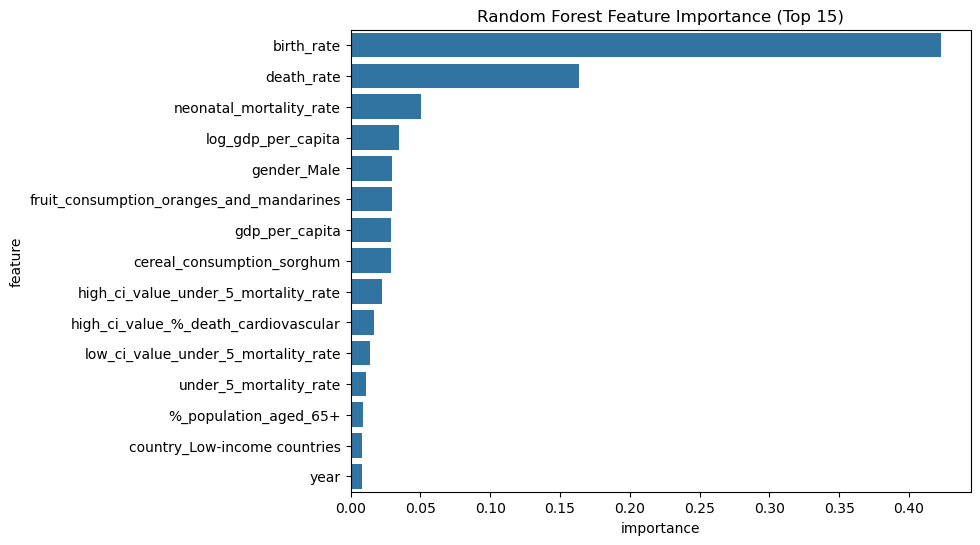

In [61]:
plt.figure(figsize=(8,6))
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title("Random Forest Feature Importance (Top 15)")
plt.show()


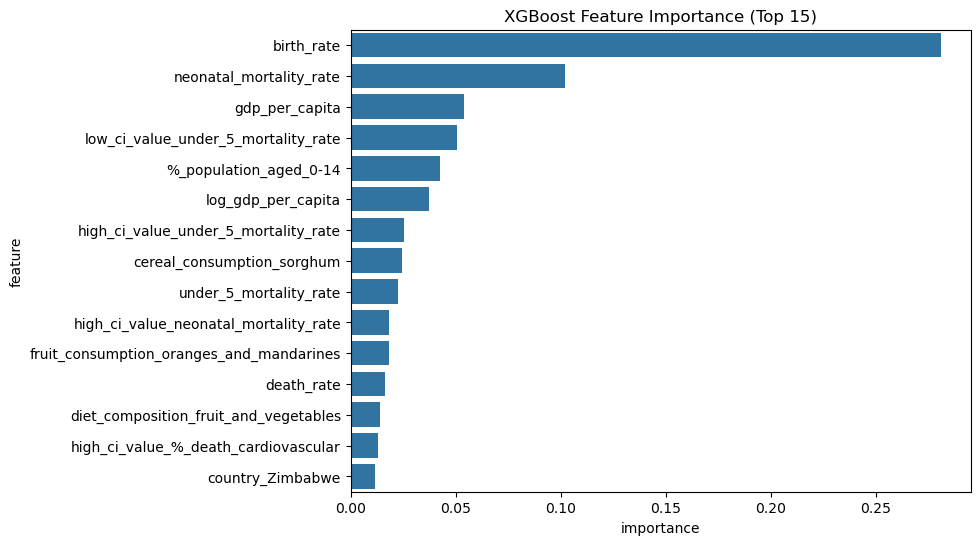

In [62]:
xgb_importance = pipe_xgb.named_steps['model'].feature_importances_
fi_xgb = pd.DataFrame({'feature': feature_names, 'importance': xgb_importance})
fi_xgb = fi_xgb.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=fi_xgb, x='importance', y='feature')
plt.title("XGBoost Feature Importance (Top 15)")
plt.show()


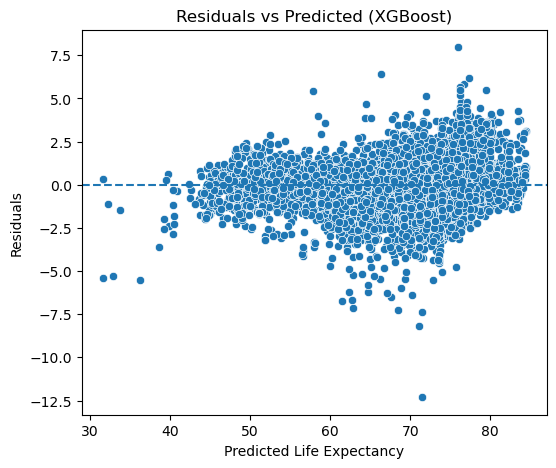

In [63]:
y_pred_best = pipe_xgb.predict(X_test)
residuals = y_test - y_pred_best

plt.figure(figsize=(6,5))
sns.scatterplot(x=y_pred_best, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Life Expectancy")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (XGBoost)")
plt.show()


In [3]:
y = df["life_expectancy"]


NameError: name 'df' is not defined

In [1]:
median_life = y.median()
y_class = (y >= median_life).astype(int)


NameError: name 'y' is not defined

In [2]:
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

pipe_xgb_clf = Pipeline([
    ('preproc', preprocessor),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])

pipe_xgb_clf.fit(X_train, y_train)


NameError: name 'train_test_split' is not defined

In [ ]:
from sklearn.metrics import roc_curve, auc

y_probs = pipe_xgb_clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Life Expectancy Classification)")
plt.legend()
plt.grid(True)
plt.show()


![8](8_Clustering-Countries-by-Health-Patterns.png)

In [67]:
features = [
    "life_expectancy",
    "gdp_per_capita",
    "under_5_mortality_rate",
    "government_expenditure_health",
    "total_population"
]

cluster_df = df[features].dropna().copy()

cluster_df.head()


,life_expectancy,gdp_per_capita,under_5_mortality_rate,government_expenditure_health,total_population
36,56.784,179.426611,120.4,0.550723,22600770.0
37,58.080,179.426611,116.2,0.550723,22600770.0
38,55.583,179.426611,124.5,0.550723,22600770.0
39,57.271,190.683814,116.3,0.607900,23680871.0
40,58.578,190.683814,112.0,0.607900,23680871.0


In [68]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)


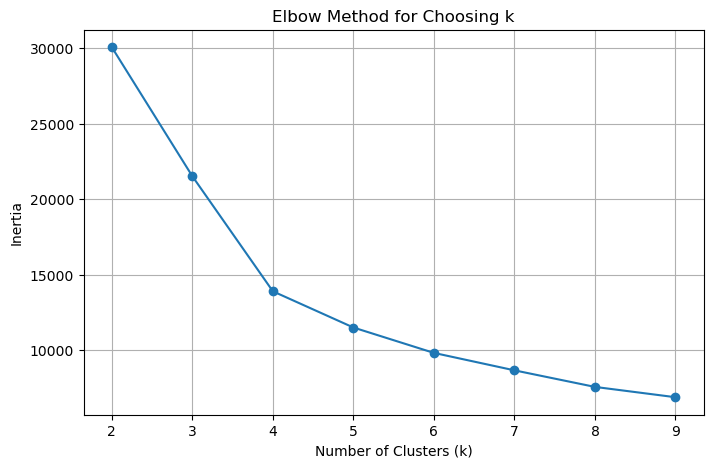

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing k")
plt.grid(True)
plt.show()


In [76]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

cluster_df["cluster"] = clusters


In [71]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

cluster_df["PC1"] = X_pca[:,0]
cluster_df["PC2"] = X_pca[:,1]

print("Explained variance ratios:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())


Explained variance ratios: [0.53200983 0.20826034]
Total variance explained: 0.7402701691420022


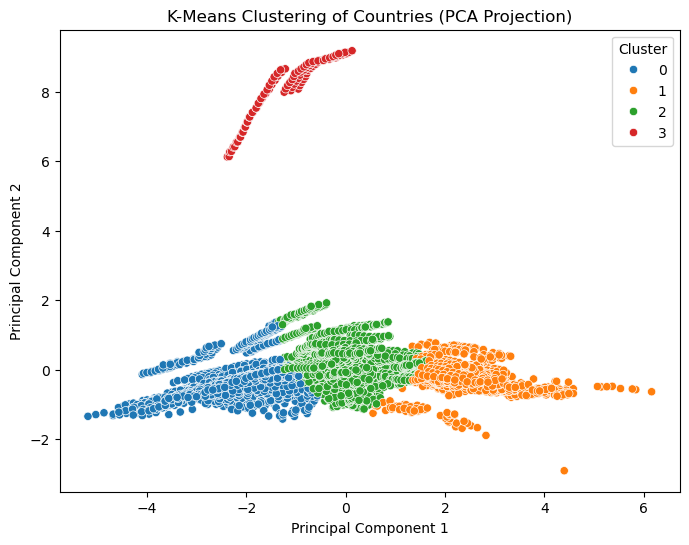

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=cluster_df,
    x="PC1", y="PC2",
    hue="cluster", palette="tab10"
)

plt.title("K-Means Clustering of Countries (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


In [73]:
cluster_summary = cluster_df.groupby("cluster")[features].mean()
cluster_summary


,life_expectancy,gdp_per_capita,under_5_mortality_rate,government_expenditure_health,total_population
cluster,,,,,
0,54.802431,1233.346247,118.400539,2.306545,2.067973e+07
1,79.114807,37402.809306,6.524010,6.679878,2.065826e+07
2,71.759188,6315.124580,23.989760,3.496693,2.057235e+07
3,68.603983,1783.530991,52.032083,1.631955,1.215038e+09


![9](9_Ethical-Considerations.png)

![10](10_Key-Recommendations.png)